# Øvelser: tekst som data

**Social Data Science 1: lektion 7**

Øvelserne bruger det datasæt, vi har preprocesseret sammen, `ft_lovforslag.csv`: 3.070 debatter
fra 1. behandlingen af lovforslag i Folketinget, oktober 2007 til november 2022.

**Del A** er simple, deskriptive **bag-of-word**s-øvelser: tæl ord, find de hyppigste, se på
fordelingen. **Del B** bygger videre på det, I så i slides, men som mere "rigtige"
undersøgelser.

Under **Hjælp** står, hvor I har set de funktioner, I skal bruge:

- **Slides**: lektion 7-slides, med navnet på slidet.
- **Preprocess-notebooken**: `l7_preprocess_dkparl_trinvis`, med trinnets nummer.
- **spaCy-notebooken**: `l7_spacy_supplement`, med trinnets nummer.

---

## Opsætning

Kør cellerne. De indlæser data og definerer stopordslisten fra slides (*Fra tekst til tabel*).
Ret stien, så den peger på jeres egen kopi af `ft_lovforslag.csv`.

In [1]:
import pandas as pd
import numpy as np
from plotnine import *


sti = "/Users/jeppefl/Library/CloudStorage/OneDrive-AalborgUniversitet/01_work/01_undervisning/02_sds1/01_slides/lektion-7/resources/ft_lovforslag.csv"
korpus = pd.read_csv(sti)

print(korpus.shape)
print(korpus.columns.tolist())

(3070, 9)
['id', 'dato', 'aar', 'samling', 'lovnr', 'titel', 'minister', 'omraade', 'tekst']


In [2]:
stopord = set("""og i jeg det at en den til er som på de med han af for ikke
der var mig sig men et har om vi min havde ham hun nu over da fra du ud sin dem
os op man hans hvor eller hvad skal selv her alle vil blev kunne ind når være dog
jo dette dig deres end mit også under have dens hvis dine disse hvem vores jer
sådan andre nogle bliver blive kan så ved mod meget rigtig tak hr fru ordfører
ordføreren forslag lovforslag lovforslaget minister ministeren værsgo altså godt
synes mener bare lige hele netop sige siger""".split())

print(len(stopord), "stopord")

104 stopord


Hele materialet er cirka 22 millioner ord. Tabellen med ét ord per række, som I laver i A2 og
A4, fylder derfor en del i hukommelsen. Har jeres computer under 8 GB RAM, så arbejd på et
udsnit ved at køre denne linje efter indlæsningen:

```python
korpus = korpus.sample(1000, random_state=1)
```

---

# Del A: Bag-of-words, deskriptivt

Her gør vi det, I kender fra lektion 6, hvor vi deler teksterne op i ord og tæller. Målet er at få en
fornemmelse for materialet, før vi analyserer det.

---

## A1. Overblik over korpusset

Før vi tæller ord, skal vi vide, hvad vi har, herunder hvor mange debatter er der fra hvert
politikområde og hvert år?

**Opgave:**

1. Tæl antallet af debatter per politikområde (`omraade`).
2. Tæl antallet af debatter per år (`aar`), sorteret efter år.
3. Lav en krydstabel med år som rækker og politikområde som kolonner.

**Hjælp:**

- Preprocess-notebooken, trin 9 og 10: `.value_counts()` på `omraade` og `.value_counts().sort_index()` på `aar`.
- Slides, *Validering først*: `pd.crosstab()` med to kolonner.

In [3]:
# Din kode her
print(korpus["omraade"].value_counts())
print()
print(korpus["aar"].value_counts().sort_index())

omraade
Andet             1242
Skat               373
Miljø og klima     366
Retsvæsen          361
Beskæftigelse      301
Uddannelse         273
Udlændinge         154
Name: count, dtype: int64

aar
2007     41
2008    223
2009    204
2010    217
2011    171
2012    229
2013    214
2014    185
2015    192
2016    205
2017    224
2018    235
2019    186
2020    226
2021    209
2022    109
Name: count, dtype: int64


In [4]:
omraade_aar = pd.crosstab(korpus["aar"], korpus["omraade"])

print(omraade_aar)

omraade  Andet  Beskæftigelse  Miljø og klima  Retsvæsen  Skat  Uddannelse  \
aar                                                                          
2007         8              5              10          2    11           5   
2008        84             19              25         25    33          25   
2009        69             18              30         26    27          25   
2010        88             29              16         28    23          25   
2011        67             15              21         29    21          10   
2012       101             23              30         23    27          25   
2013       106             13              30         36    15          14   
2014        78             18              21         26    23          19   
2015        84             24              23         17    24          11   
2016        94             16              23         23    16          15   
2017        92             15              31         23    23  

**Kig efter i viewer:** Åbn krydstabellen. Hvilke celler er små? Find kolonnen `Udlændinge`.

**Til diskussion:**

- Hvorfor er der færre debatter i 2007 og 2022?
- Hvor mange debatter om Udlændinge er der typisk per år? Hvad betyder det, hvis vi vil sige
  noget om udviklingen over tid inden for ét område?

*Jeres svar:*

---

## A2. Fra tekst til ord

Brug opskriften fra slides til at lave teksterne om til én lang Series med ét ord per række.
Indekset husker, hvilken debat ordet kom fra.

**Opgave:**

1. Lav en Series `ord`: små bogstaver, erstat alt, der ikke er bogstaver, tal eller mellemrum,
   med mellemrum, del op, og fold ud.
2. Hvor mange **tokens** og hvor mange **typer** er der?
3. Tæl antallet af ord i hver debat, og gem det som en ny kolonne `n_ord` i `korpus`.
4. Beskriv fordelingen af `n_ord`, og lav en oversigt med antal debatter og medianen af `n_ord`
   for hvert politikområde.

**Hjælp:**

- Slides, *Hvordan den scorer*: hele opskriften fra `korpus["tekst"]` til `.explode()`.
- Slides, *Kør den på korpusset*: `.groupby(level=0)` grupperer efter debatten.
- Preprocess-notebooken, trin 5.2: `oversigt` med `.agg(antal="size", median_tegn="median")`.

In [5]:
# Din kode her
ord = (korpus["tekst"].astype(str)
       .str.lower()
       .str.replace(r"[^\wæøå ]", " ", regex=True)
       .str.split()
       .explode())

print("tokens:", len(ord), "| typer:", ord.nunique())

tokens: 21882341 | typer: 151811


In [6]:
korpus["n_ord"] = ord.groupby(level=0).size()

print(korpus["n_ord"].describe().round(0))

count     3070.0
mean      7128.0
std       7815.0
min        414.0
25%       3101.0
50%       5004.0
75%       8701.0
max      98087.0
Name: n_ord, dtype: float64


In [7]:
oversigt = (korpus
            .groupby("omraade")["n_ord"]
            .agg(antal="size", median_ord="median")
            .sort_values("median_ord", ascending=False))

print(oversigt)

                antal  median_ord
omraade                          
Udlændinge        154      6226.0
Retsvæsen         361      5306.0
Skat              373      5269.0
Andet            1242      5042.0
Miljø og klima    366      4841.5
Beskæftigelse     301      4809.0
Uddannelse        273      4328.0


**Kig efter i viewer:** Sortér `korpus` efter `n_ord`. Hvilke debatter er de korteste og de længste? Hvad handler de om?

**Til diskussion:**

- Hvor meget varierer antallet af ord fra debat til debat?
- Hvilke politikområder har de længste debatter? Er antal ord et godt mål for, hvor meget en
  debat fylder politisk?
- Slides målte temaer *per 1.000 ord*. Hvorfor er det nødvendigt her?

*Jeres svar:*

---

## A3. De hyppigste ord, og hvad stopordene fjerner

Hvilke ord bruges mest i Folketinget? Først uden at fjerne noget, derefter uden stopord. Vi
fører regnskab med tokens og typer, som i spaCy-notebooken.

**Opgave:**

1. Find de 20 hyppigste ord i `ord`.
2. Lav tabellen `kaede` og funktionen `tael()` fra spaCy-notebooken, og tæl `ord`.
3. Lav en tabel `fjernet_w` med de fjernede stopord og deres antal. Fjern stopordene, gem
   resultatet som `indhold`, og tæl igen.
4. Find de 25 hyppigste ord i `indhold`.

**Hjælp:**

- spaCy-notebooken, trin 4: `kaede` og `tael()`.
- spaCy-notebooken, trin 5.4: `fjernet_w` med `.value_counts().reset_index()`, og filteret `~ ... .isin(stopord)`.
- Slides, *Hvad fylder i scoren?*: `.value_counts().head()`.

In [8]:
# Din kode her
print(ord.value_counts().head(20))

tekst
det     957924
at      943920
er      762277
og      563950
i       556199
der     446215
vi      403810
for     399975
til     393663
en      346931
jeg     291523
som     278593
ikke    276949
på      276283
har     272387
de      261656
den     257765
af      254366
man     249808
så      236048
Name: count, dtype: int64


In [9]:
kaede = pd.DataFrame(columns=["trin", "tokens", "typer"])

def tael(trin, former):
    kaede.loc[len(kaede)] = [trin, len(former), former.nunique()]
    print(kaede)

tael("Rå tokens", ord)

        trin    tokens   typer
0  Rå tokens  21882341  151811


In [10]:
fjernet_w = ord[ord.isin(stopord)].value_counts().reset_index()

indhold = ord[~ord.isin(stopord)]

tael("+ fjern stopord", indhold)

              trin    tokens   typer
0        Rå tokens  21882341  151811
1  + fjern stopord   9201183  151707


In [11]:
print(indhold.value_counts().head(25))

tekst
noget           55478
få              51562
derfor          50487
får             41146
mange           39913
været           39763
kommer          39403
dansk           37581
danmark         37286
mere            35591
gerne           35513
dag             34710
forhold         33837
helt            33086
må              32847
gøre            32644
fordi           32093
flere           31873
gør             31240
år              31169
set             30025
selvfølgelig    29434
faktisk         28959
lidt            27775
folkeparti      27611
Name: count, dtype: int64


**Kig efter i viewer:** Åbn `fjernet_w`. Hvor langt nede på listen skal I, før I finder et ord, I ville have beholdt?

**Til diskussion:**

- Hvilke ord dominerer, før stopordene er fjernet? Står der noget, der siger noget om politik?
- Fjerner stopordene flest tokens eller flest typer? Er mønsteret det samme som i spaCy-notebooken?
- Hvilke ord i top 25 efter stopordene overrasker jer? Kan I forklare, hvorfor de er der?

*Jeres svar:*

---

## A4. De hyppigste ord per politikområde

Kan man se forskel på politikområderne ud fra de hyppigste ord? For at koble ordene til
områderne laver vi tabellen `lang` fra slides med ét ord per række og år og område ved siden af.

**Opgave:**

1. Lav tabellen `lang` ud fra `ord` og kobl `aar` og `omraade` på fra `korpus`.
2. Lav `indhold` om, så den er `lang` uden stopord.
3. Find de 10 hyppigste ord i hvert politikområde, og vis dem som én liste per område.

**Hjælp:**

- Slides, *Tre temaordbøger*: `ord.rename("ord").to_frame().join(korpus[["aar", "omraade"]])`.
- spaCy-notebooken, trin 5.6: `fjernet_pos` med `.groupby(...)[...].value_counts().groupby(level=0).head(10)`.
- Slides, *Hvad handler klyngerne om?*: `.groupby(...)["ord"].agg(list)`.

In [12]:
# Din kode her
lang = ord.rename("ord").to_frame().join(korpus[["aar", "omraade"]])

indhold = lang[~lang["ord"].isin(stopord)]

print(indhold.head())

             ord   aar         omraade
0  forhandlingen  2014  Miljø og klima
0          åbnet  2014  Miljø og klima
0         første  2014  Miljø og klima
0          ordet  2014  Miljø og klima
0           lars  2014  Miljø og klima


In [13]:
top10 = (indhold
         .groupby("omraade")["ord"]
         .value_counts()
         .groupby(level=0)
         .head(10)
         .reset_index())

print(top10.groupby("omraade")["ord"].agg(list))

omraade
Andet             [noget, derfor, få, mange, får, været, gerne, ...
Beskæftigelse     [få, noget, derfor, får, arbejde, kommer, mang...
Miljø og klima    [noget, derfor, få, får, forhold, mere, kommer...
Retsvæsen         [noget, derfor, få, været, må, dag, kommer, da...
Skat              [noget, derfor, få, mere, været, danmark, kr, ...
Uddannelse        [derfor, få, noget, mange, får, unge, været, f...
Udlændinge        [danmark, dansk, få, danske, noget, kommer, de...
Name: ord, dtype: object


**Kig efter i viewer:** Åbn `top10` (eller hvad i kalder variablen), og filtrér på ét område ad gangen.

**Til diskussion:**

- Hvor mange af de ti hyppigste ord er ens på tværs af områderne?
- Hvilke ord gør det muligt at genkende et område?
- Hvad fortæller det om hyppighed som mål for, hvad der er *særligt* for et område?

*Jeres svar:*

---

## A5. Få ord bruges meget, mange ord bruges sjældent

Ordfrekvenser er meget skævt fordelt. Det er grunden til, at en document-term matrix er næsten
tom (slides, *Document-term matrix*).

**Opgave:**

1. Hvor mange typer optræder kun én gang i hele korpusset (*hapax*)? Hvor stor en andel af alle
   typer er det?
2. Hvor stor en andel af alle tokens udgør de 10 hyppigste ord?
3. Beregn dokumentfrekvensen: i hvor mange debatter står hvert ord? Hvor mange typer står kun
   i én debat?
4. *(Valgfri)* Tegn ordenes frekvens mod deres rang med logaritmiske akser.

**Hjælp:**

- spaCy-notebooken, trin 5.7: `dokfrekvens` og `(dokfrekvens == 1).sum()`.
- Slides, *Document-term matrix*: `ord.rename("ord").reset_index().drop_duplicates()["ord"].value_counts()`.
- Slides, *Tegn det*: plotnine. Brug `scale_x_log10()` og `scale_y_log10()`.

In [14]:
# Din kode her
frekvens = ord.value_counts()

print("Hapax:", (frekvens == 1).sum(), "| andel af typer:", round((frekvens == 1).mean(), 3))
print("Top 10's andel af tokens:", round(frekvens.head(10).sum() / frekvens.sum(), 3))

Hapax: 65878 | andel af typer: 0.434
Top 10's andel af tokens: 0.264


In [15]:
dokfrekvens = ord.rename("ord").reset_index().drop_duplicates()["ord"].value_counts()

print("Typer i kun én debat:", (dokfrekvens == 1).sum(), "af", len(dokfrekvens))

Typer i kun én debat: 78016 af 151811


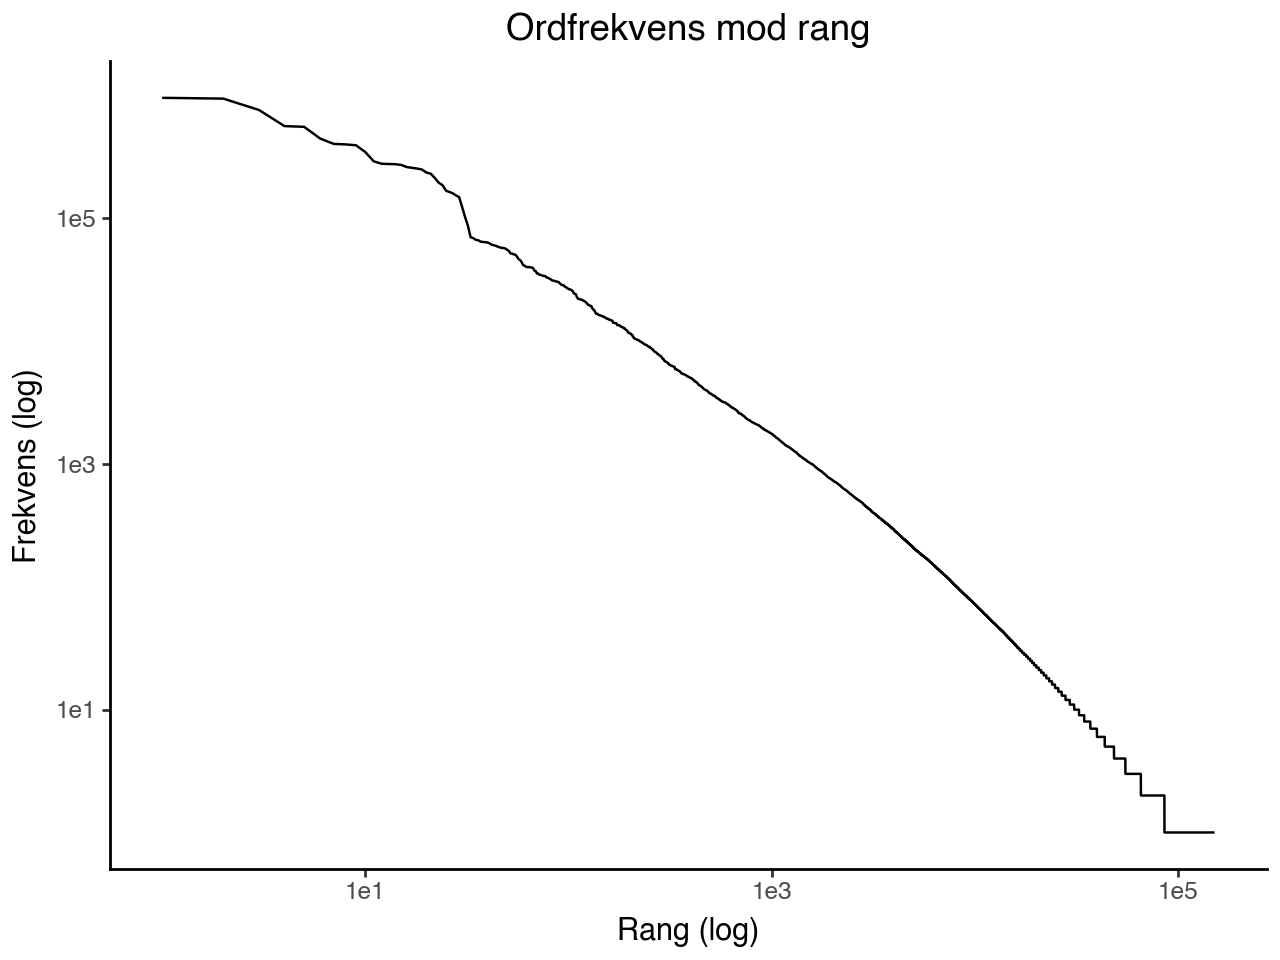

In [19]:
plot = frekvens.reset_index(drop=True).rename("frekvens").to_frame()
plot["rang"] = plot.index + 1

(ggplot(plot, aes(x="rang", y="frekvens"))
 + geom_line()
 + scale_x_log10()
 + scale_y_log10()
 + labs(x="Rang (log)", y="Frekvens (log)", title="Ordfrekvens mod rang")
 + theme_classic())

**Kig efter i viewer:** Åbn `frekvens`. Rul til bunden. Hvilke slags ord står kun én gang?

**Til diskussion:**

- Hvad betyder fordelingen for en DTM med én kolonne per type?
- Er ord, der kun står i én debat, støj? Giv et eksempel på, hvornår de kunne være det
  interessante.

*Jeres svar:*

---

## A6. Tilbage til teksten: konkordans

Et ord, der tælles, skal også læses i sin sammenhæng. Vi ser på ordet *retssikkerhed*.

**Opgave:**

1. Tæl, hvor mange gange *retssikkerhed* (inklusive bøjninger som *retssikkerheden*) står i hver
   debat. Lav en oversigt per politikområde med antal forekomster og antal debatter, der nævner
   ordet.
2. Hvilket område nævner ordet flest gange? Hvilke enkeltdebatter nævner det mest?
3. Lav en konkordans: find ordet med 60 tegn før og efter, og læs 8 tilfældige eksempler fra det
   område, der nævner ordet mest.

**Hjælp:**

- Slides, *Tilbage til teksten*: `.str.findall(r"(?i).{0,60}\b\w*krise\w*.{0,60}")`, `.explode()`, `.dropna()` og `.sample(8, random_state=1)`.
- Preprocess-notebooken, trin 9: `.str.contains()`. Her skal I bruge `.str.count()`, som tæller i stedet.
- Preprocess-notebooken, trin 5.2: `.agg(...)` med navngivne kolonner.

In [20]:
# Din kode her
korpus["retssikkerhed"] = korpus["tekst"].str.count(r"(?i)\bretssikkerhed\w*")

oversigt = (korpus
            .groupby("omraade")["retssikkerhed"]
            .agg(forekomster="sum", debatter=lambda s: (s > 0).sum())
            .sort_values("forekomster", ascending=False))

print(oversigt)
print()
print(korpus.nlargest(5, "retssikkerhed")[["aar", "omraade", "titel", "retssikkerhed"]])

                forekomster  debatter
omraade                              
Andet                  1005       263
Retsvæsen               985       181
Skat                    493        69
Udlændinge              316        57
Miljø og klima          175        51
Beskæftigelse           143        48
Uddannelse               67        25

       aar    omraade                                              titel  \
2841  2009  Retsvæsen  1. behandling af L 124: Om retsplejeloven (tel...   
3064  2015       Skat  1. behandling af L 13: Om ophævelse af hjemmel...   
1417  2013       Skat  1. behandling af L 212: Om ny klagestruktur på...   
2823  2016       Skat  1. behandling af L 28: Om opfølgning på retssi...   
2438  2013      Andet  1. behandling af L 158: Om forenkling af klage...   

      retssikkerhed  
2841             79  
3064             67  
1417             48  
2823             48  
2438             42  


In [ ]:
eksempler = (korpus["tekst"]
             .str.findall(r"(?i).{0,60}\bretssikkerhed\w*.{0,60}")
             .explode()
             .dropna()
             .str.replace("\n", " "))

oeverst = oversigt.index[0]
fra_omraadet = eksempler[korpus.loc[eksempler.index, "omraade"] == oeverst]

for linje in fra_omraadet.sample(8, random_state=1):
    print("...", linje, "...")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x107c92f40>>
Traceback (most recent call last):
  File "/Users/jeppefl/Library/Python/3.9/lib/python/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


... res konklusion er, at flere af forsøgene antaster borgerens retssikkerhed og deres krav på en ordentlig service. Disse dele af forsøg ...
... institution foretager sejlads med elever, og dermed styrkes retssikkerheden og mulighederne for at få erstatning ved ulykker som f.eks. ...
... r bare at sige, at det er o.k., og at det må vi ikke krænke retssikkerhedsmæssigt, er det så bare helt konkret o.k., at man markedsfører eufo ...
... nye bestemmelser på psykiatriområdet, som bl.a. skal styrke retssikkerheden og skabe mere tryghed og bedre arbejdsvilkår på de psykiatr ...
... ligområder, og så kan man jo gøre sig forskellige tanker om retssikkerhed, og den diskussion er jeg selvfølgelig villig til at tage.  ...
... viceniveauer i kommunerne og om, hvordan vi sikrer en bedre retssikkerhed, og også om, hvordan vi kan gøre noget i nogle af de sager, ...
... Vi mener, at der er fundet en god balance mellem retssikkerhed og en mere effektiv klagebehandling, og vi forudser, at lov ...
...  

**Kig efter i viewer:** Sortér `korpus` efter `retssikkerhed`. Læs titlerne på de debatter, der nævner ordet mest.

**Til diskussion:**

- Havde I forventet det område? Hvad handler retssikkerhed om, når det bruges der?
- Hvor mange debatter står bag tallet? Hvad betyder det for, hvordan tallet kan tolkes?

*Jeres svar:*

---

# Del B: Udvidelser

Øvelserne bygger videre på det, I så i slides. Hver øvelse tager én metode og gør den mere
"nuanceret".

Øvelserne bruger `ord`, `lang` og `indhold` fra Del A. Kør Del A først.

---

## B1. Nøgleord: hvad er særligt for et område?

A4 viste, at de hyppigste ord er de samme overalt. **Nøgleord** (*keyness*, Hunston) er ord,
der er hyppigere i ét delkorpus end i resten. Et enkelt mål er **log-ratio**, som er log2 af forholdet
mellem ordets relative frekvens i området og i resten af korpusset.

$$\text{log-ratio} = \log_2 \frac{(n + 0{,}5) / N_{\text{område}}}{(n_{\text{rest}} + 0{,}5) / N_{\text{rest}}}$$

En log-ratio på 1 betyder, at ordet er dobbelt så hyppigt i området som i resten. Værdien 0,5 indgår i ligningen, så vi ikke dividerer med 0, når et ord slet ikke står i resten.

**Opgave:**

Brug `indhold` (uden stopord).

1. Tæl, hvor mange gange hvert ord står i hvert område: en tabel med kolonnerne `omraade`,
   `ord` og `n`.
2. Tilføj `N_omr` (antal ord i området i alt) og `n_alle` (ordets antal i hele korpusset).
3. Beregn `n_rest`, `N_rest` og `log_ratio`.
4. Behold ord med `n >= 50`, og find de 8 ord med højest log-ratio i hvert område.

**Hjælp:**

- Slides, *TF-IDF*: `dtm.div(dtm.sum(axis=1), axis=0)` giver relative frekvenser, og `np.log()`. Her skal I bruge `np.log2()`.
- `.groupby(...)["n"].transform("sum")` giver summen for gruppen på hver række, så den kan bruges i en beregning række for række.
- spaCy-notebooken, trin 5.6: `.groupby(level=0).head(10)`. Her grupperer I på `"omraade"`.

In [22]:
# Din kode her
n = indhold.groupby(["omraade", "ord"]).size().rename("n").reset_index()

In [23]:
n["N_omr"] = n.groupby("omraade")["n"].transform("sum")
n["n_alle"] = n.groupby("ord")["n"].transform("sum")
n["n_rest"] = n["n_alle"] - n["n"]
n["N_rest"] = n["n"].sum() - n["N_omr"]

In [24]:
n["log_ratio"] = np.log2(((n["n"] + 0.5) / n["N_omr"]) /
                         ((n["n_rest"] + 0.5) / n["N_rest"]))

In [25]:
noegleord = (n[n["n"] >= 50]
             .sort_values("log_ratio", ascending=False)
             .groupby("omraade")
             .head(8))

print(noegleord.groupby("omraade")["ord"].agg(list))

omraade
Andet             [sundhedspersoner, tandpleje, klinikker, patie...
Beskæftigelse     [feriedagpenge, jobafklaringsforløb, lønstrukt...
Miljø og klima    [havbrug, efterafgrøder, landbrugskommissionen...
Retsvæsen         [peberspray, postlister, prøveløsladelse, tigg...
Skat              [cfc, pvc, dbo, substanstest, retssikkerhedspa...
Uddannelse        [skolelederen, kompetencebevis, gymnasiereform...
Udlændinge        [rejselegitimation, modtagecenter, transportør...
Name: ord, dtype: object


**Kig efter i viewer:** Åbn `n` (eller hvad i kalder jeres variabel), og sortér efter `log_ratio`. Hvad står øverst, hvis I ikke har fjernet de sjældne ord?

**Til diskussion:**

- Sammenlign med A4. Er det nu lettere at genkende områderne?
- Nogle nøgleord er **personnavne**. Hvorfor? Hvad betyder det, hvis vi i en klyngeanalyse vil
  finde områderne ud fra, *hvad der tales om*?
- Hvorfor kræver vi en nedre grænse for `n`?

*Jeres svar:*

---

## B2. Et tema, debat for debat og med usikkerhed

I slides målte vi temaer ved at lægge alle ord fra et år sammen (*Over tid*). Her måler vi i
stedet **per debat** og spørger, hvor sikre tallene er. Vi bruger udlændingeordbogen fra slides.

**Opgave:**

```python
udl = ["udlændinge", "flygtninge", "asyl", "asylansøgere",
       "indvandrere", "integration", "opholdstilladelse", "udvisning"]
```

1. Lav kolonnen `udl` i `lang`: `True` for hvert ord, der står i `udl`.
2. Beregn for hver debat, hvor mange udlændingeord der er per 1.000 ord. Gem det som kolonnen
   `udl` i `korpus`.
3. Hvor stor en andel af debatterne har værdien 0? Lav en oversigt med gennemsnit, median og
   andel med 0 for hvert politikområde.
4. Beregn for hvert år både det samlede mål fra slides (alle ord i året lagt sammen) og
   gennemsnittet af debatterne. Sammenlign dem.
5. Lav et 95 %-bootstrap-interval for gennemsnittet i hvert år: træk debatter med tilbagelægning
   inden for hvert år 500 gange, og tag 2,5 %- og 97,5 %-fraktilen.
6. Tegn gennemsnittet og intervallet over tid.

**Hjælp:**

- Slides, *Mål: per 1.000 ord*: `lang["ord"].isin(kriseord)` og `lang.groupby("aar")[...].mean() * 1000`.
- Slides, *Kør den på korpusset*: `.groupby(level=0)` giver én værdi per debat.
- Preprocess-notebooken, trin 5.2: `.agg(...)` med navngivne kolonner.
- Bootstrap: `korpus.groupby("aar").sample(frac=1, replace=True, random_state=i)` trækker én ny stikprøve. Gentag med en list comprehension, og saml med `pd.concat(..., axis=1)` og `.quantile(0.025, axis=1)`.
- Slides, *Rammer data forudsigelsen?*: plotnine. Intervallet tegnes med `geom_ribbon(aes(ymin=..., ymax=...))`.

In [26]:
# Din kode her
udl = ["udlændinge", "flygtninge", "asyl", "asylansøgere",
       "indvandrere", "integration", "opholdstilladelse", "udvisning"]

lang["udl"] = lang["ord"].isin(udl)

In [27]:
korpus["udl"] = lang["udl"].groupby(level=0).mean() * 1000

print(korpus["udl"].describe().round(2))
print()
print("Andel debatter med 0:", round((korpus["udl"] == 0).mean(), 3))
print()
print(korpus.groupby("omraade")["udl"].agg(
    gennemsnit="mean",
    median="median",
    andel_nul=lambda s: (s == 0).mean()).round(2))

count    3070.00
mean        0.38
std         1.59
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        30.99
Name: udl, dtype: float64

Andel debatter med 0: 0.824

                gennemsnit  median  andel_nul
omraade                                      
Andet                 0.11    0.00       0.87
Beskæftigelse         0.22    0.00       0.85
Miljø og klima        0.03    0.00       0.97
Retsvæsen             0.42    0.00       0.73
Skat                  0.04    0.00       0.91
Uddannelse            0.17    0.00       0.84
Udlændinge            4.79    3.99       0.01


In [28]:
pr_aar = pd.DataFrame({
    "samlet": lang.groupby("aar")["udl"].mean() * 1000,
    "gns_debat": korpus.groupby("aar")["udl"].mean(),
}).round(2)

print(pr_aar)

      samlet  gns_debat
aar                    
2007    0.04       0.02
2008    0.15       0.13
2009    0.26       0.20
2010    0.32       0.19
2011    0.33       0.26
2012    0.21       0.15
2013    0.30       0.32
2014    0.50       0.30
2015    0.87       0.59
2016    0.62       0.46
2017    0.67       0.67
2018    0.62       0.63
2019    0.49       0.42
2020    0.50       0.57
2021    0.38       0.32
2022    0.72       0.66


In [29]:
traek = pd.concat([korpus.groupby("aar")
                         .sample(frac=1, replace=True, random_state=i)
                         .groupby("aar")["udl"].mean()
                   for i in range(500)], axis=1)

usikkerhed = pd.DataFrame({
    "gns": korpus.groupby("aar")["udl"].mean(),
    "nedre": traek.quantile(0.025, axis=1),
    "oevre": traek.quantile(0.975, axis=1),
}).round(2)

print(usikkerhed)

       gns  nedre  oevre
aar                     
2007  0.02   0.00   0.06
2008  0.13   0.07   0.20
2009  0.20   0.09   0.31
2010  0.19   0.07   0.32
2011  0.26   0.10   0.50
2012  0.15   0.05   0.26
2013  0.32   0.15   0.53
2014  0.30   0.15   0.49
2015  0.59   0.34   0.89
2016  0.46   0.25   0.67
2017  0.67   0.42   0.94
2018  0.63   0.38   0.91
2019  0.42   0.19   0.69
2020  0.57   0.26   1.03
2021  0.32   0.15   0.52
2022  0.66   0.34   1.01


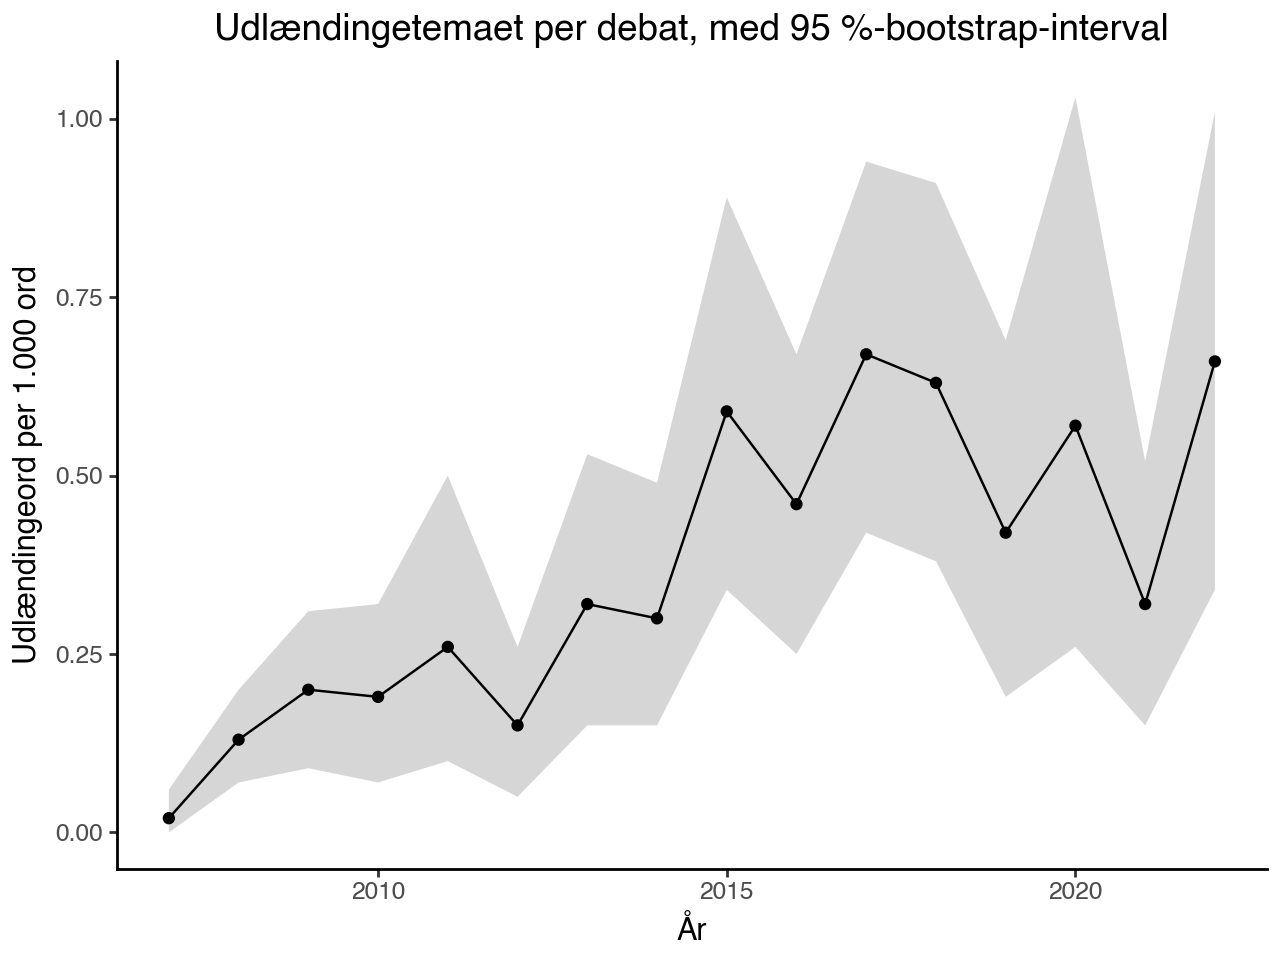

In [31]:
from plotnine import ggplot, aes, geom_ribbon, geom_line, geom_point, labs, theme_minimal

(ggplot(usikkerhed.reset_index(), aes(x="aar", y="gns"))
 + geom_ribbon(aes(ymin="nedre", ymax="oevre"), alpha=0.2)
 + geom_line()
 + geom_point()
 + labs(x="År", y="Udlændingeord per 1.000 ord",
        title="Udlændingetemaet per debat, med 95 %-bootstrap-interval")
 + theme_classic())

**Kig efter i viewer:** Sortér `korpus` efter `udl`. Hvilke debatter scorer højest? Hvilket område kommer de fra?

**Til diskussion:**

- Hvordan ser fordelingen ud? Hvad betyder det for gennemsnittet som mål?
- Hvorfor er det samlede mål og gennemsnittet af debatterne ikke det samme? Hvilke debatter
  vejer mest i det samlede mål? (Tænk på A2.)
- Kan I sige, at udlændingetemaet fyldte mere i 2015-2017 end i årene før? Hvor brede er
  intervallerne?

*Jeres svar:*